# 5.1 Field of View Constraints

FOV = 5 half-spaces in body frame:
| Constraint | Body-frame inequality |
|------------|----------------------|
| Left | $-\tan(\alpha_h/2)x - y \leq 0$ |
| Right | $-\tan(\alpha_h/2)x + y \leq 0$ |
| Bottom | $-\tan(\alpha_v/2)x - z \leq 0$ |
| Top | $-\tan(\alpha_v/2)x + z \leq 0$ |
| Max depth | $x \leq d_{\max}$ |

Logistic collision cost: $J(d) = Q_o/(1+e^{\lambda_o(d-r_o)})$, $J(r_o)=Q_o/2$.

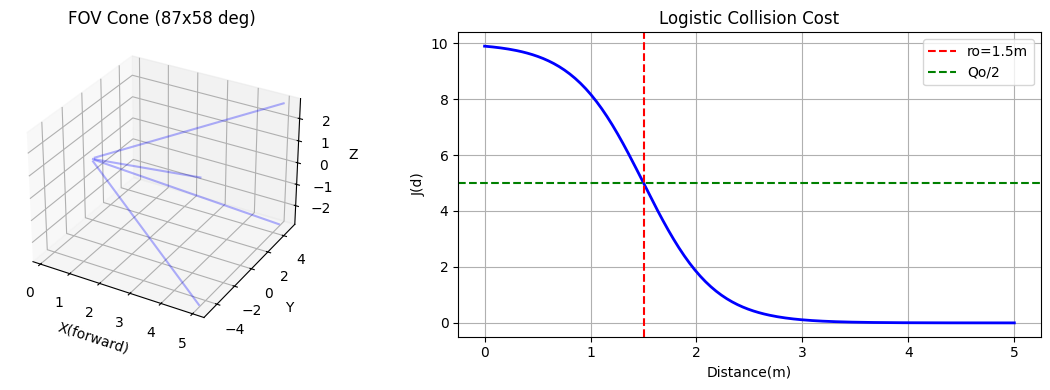

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import tan, radians
import os; os.makedirs('/home/phuc/Research/quadrotor_ccmpc/3.Notebooks/outputs', exist_ok=True)

# FOV cone visualization
hfov=radians(87);vfov=radians(58);dmax=5.0
fig=plt.figure(figsize=(12,4))
ax=fig.add_subplot(121,projection='3d')
for ys, zs in [(1,-1),(1,1),(-1,1),(-1,-1)]:
    xs=np.linspace(0.1,dmax,15)
    ax.plot(xs,ys*xs*tan(hfov/2),zs*xs*tan(vfov/2),'b-',alpha=0.3)
ax.set_xlabel('X(forward)');ax.set_ylabel('Y');ax.set_zlabel('Z')
ax.set_title('FOV Cone (87x58 deg)')

# Logistic cost
ax2=fig.add_subplot(122)
Qo,lam,ro=10,3,1.5
d=np.linspace(0,5,200)
J=Qo/(1+np.exp(lam*(d-ro)))
ax2.plot(d,J,'b-',lw=2)
ax2.axvline(ro,color='r',ls='--',label='ro=%.1fm'%ro)
ax2.axhline(Qo/2,color='g',ls='--',label='Qo/2')
ax2.set_xlabel('Distance(m)');ax2.set_ylabel('J(d)')
ax2.set_title('Logistic Collision Cost');ax2.legend();ax2.grid(True)
plt.tight_layout()
plt.savefig('/home/phuc/Research/quadrotor_ccmpc/3.Notebooks/outputs/5.1_fov.png',dpi=100,bbox_inches='tight')
plt.show()
